PCA-BASED ELBOW POINT DETECTION

✓ Loaded 168,960 matches from 528_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top528_matches_all_scores.csv

Dataset: 20 genes × 16 samples × 528 ranks

----------------------------------------------------------------------
Creating gene-sample × rank matrix...
Matrix shape: 320 observations × 528 ranks

Running PCA...

  Variance explained by top PCs:
    PC1:      75.3%
    PC1-5:    99.0%
    PC1-10:   99.8%
    PC1-20:   99.9%
    PC1-50:  100.0%

SCREE PLOT ELBOW DETECTION

  Running parallel analysis (this may take a moment)...

  Method               # PCs      Confidence   Cum. Var%   
  -------------------------------------------------------
  Geometric            6          0.66         99.3        
  Kaiser               6          0.33         99.3        
  80% Variance         2          0.70         93.8        
  90% Variance         2          0.70         93.8        
  95% Variance         3          0.70         97.4       

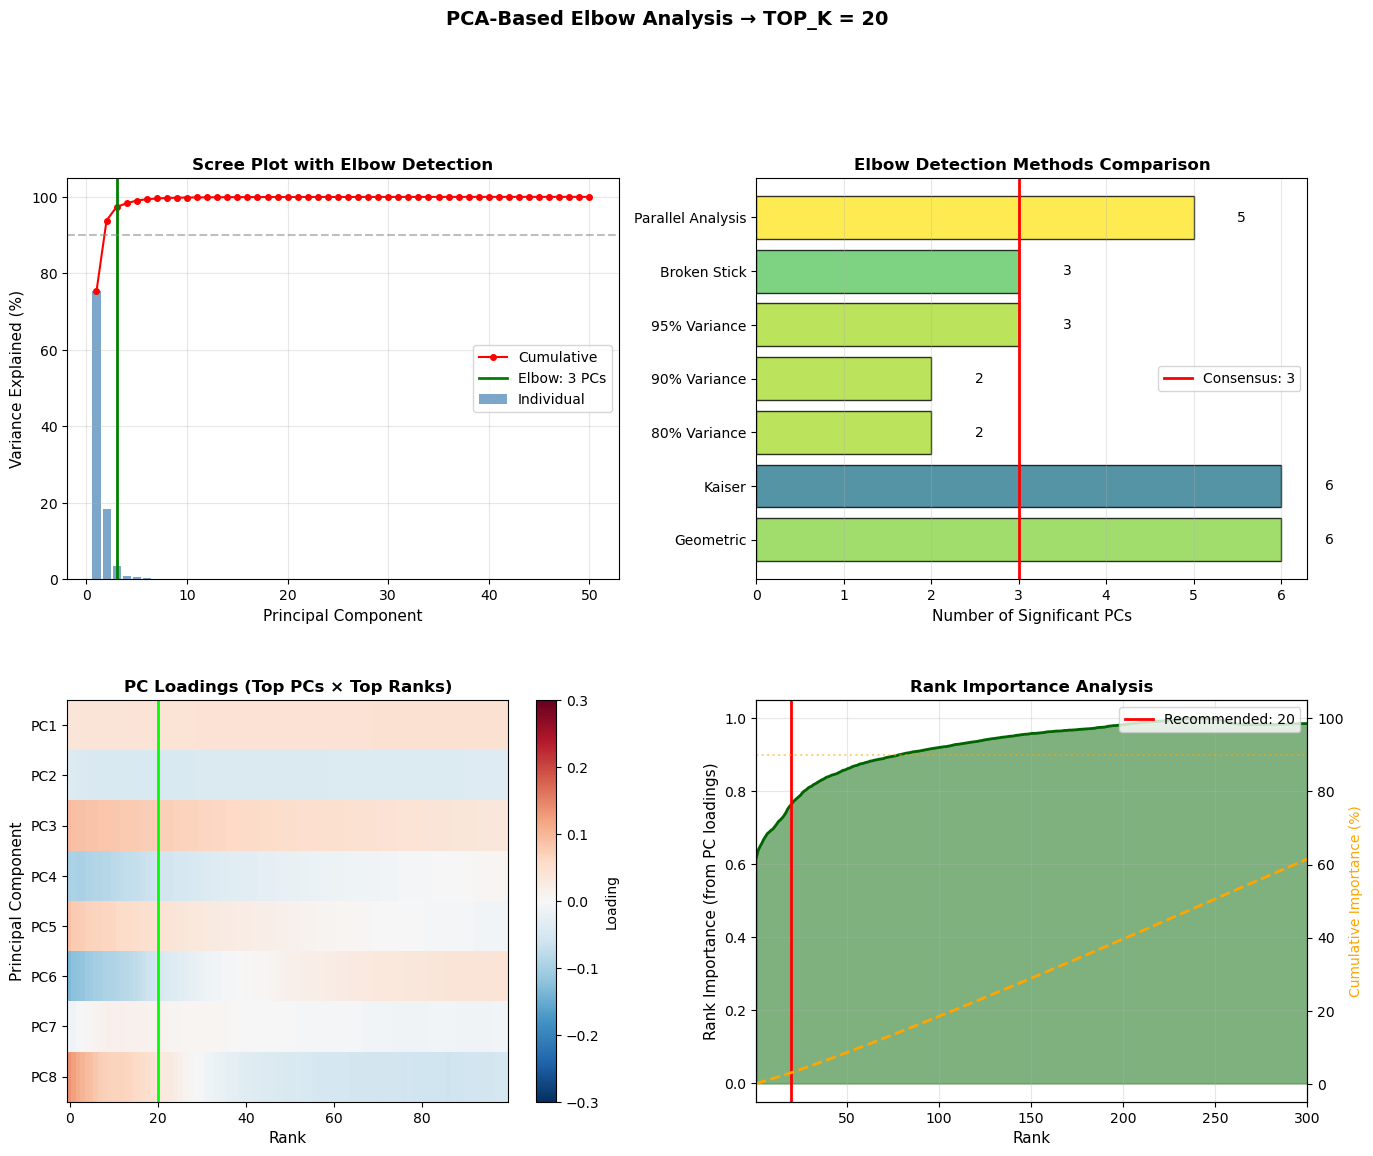


Plot saved to: pca_elbow_analysis/pca_elbow_analysis.png

SUMMARY

    PCA Analysis Results:
    
    • Significant PCs (elbow): 3
    • Variance captured: 97.4%
    
    Mapped to Rank Cutoff:
    
    ★ RECOMMENDED: TOP_K = 20
    
    Interpretation:
    The data has ~3 independent dimensions of variation.
    Ranks beyond 20 add mostly noise, not signal.
    
    For your pipeline:
    → Set TOP_K_MATCHES = 20
    → Then apply parent-child tipping within this set
    



In [8]:
"""
PCA-Based Elbow Point Detection
================================
Uses Principal Component Analysis to find the optimal TOP_K cutoff.

Key Insight:
- Create a matrix where rows = gene-sample pairs, columns = ranks
- Run PCA on this matrix
- The scree plot (variance explained per PC) has a natural elbow
- The number of significant PCs ≈ number of meaningful ranks

This is more principled than heuristic elbow detection on score curves
because it's based on the actual information content of the data.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from dataclasses import dataclass
from typing import Tuple, List, Optional
import os
import warnings
warnings.filterwarnings('ignore')


# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '528_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top528_matches_all_scores.csv'
SAVE_DIR = "pca_elbow_analysis/"
os.makedirs(SAVE_DIR, exist_ok=True)


# =============================================================================
# DATA STRUCTURES
# =============================================================================
@dataclass
class PCAElbowResult:
    """Container for PCA-based elbow detection result."""
    recommended_topk: int
    n_significant_pcs: int
    variance_at_elbow: float
    method_details: dict
    confidence: float


# =============================================================================
# PCA ELBOW DETECTION METHODS
# =============================================================================

def find_scree_elbow_geometric(explained_variance: np.ndarray) -> Tuple[int, float]:
    """
    Find elbow in scree plot using geometric (maximum distance) method.
    
    Returns: (n_components at elbow, confidence)
    """
    n = len(explained_variance)
    x = np.arange(n)
    y = explained_variance
    
    # Normalize
    x_norm = x / (n - 1)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-10)
    
    # Line from first to last point
    p1 = np.array([0, y_norm[0]])
    p2 = np.array([1, y_norm[-1]])
    
    # Calculate perpendicular distances
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unit = line_vec / (line_len + 1e-10)
    
    distances = []
    for i in range(n):
        point = np.array([x_norm[i], y_norm[i]])
        vec_to_point = point - p1
        proj_length = np.dot(vec_to_point, line_unit)
        proj_point = p1 + proj_length * line_unit
        dist = np.linalg.norm(point - proj_point)
        distances.append(dist)
    
    distances = np.array(distances)
    elbow_idx = np.argmax(distances)
    
    # Confidence based on elbow prominence
    max_dist = distances[elbow_idx]
    mean_dist = np.mean(distances)
    confidence = min(1.0, max_dist / (mean_dist + 1e-10) / 3)
    
    return elbow_idx + 1, confidence  # +1 for 1-indexed PC count


def find_scree_elbow_kaiser(explained_variance: np.ndarray, 
                            eigenvalues: np.ndarray) -> Tuple[int, float]:
    """
    Kaiser criterion: Keep PCs with eigenvalue > 1 (for standardized data)
    or eigenvalue > mean eigenvalue.
    
    Returns: (n_components, confidence)
    """
    threshold = np.mean(eigenvalues)
    n_above = np.sum(eigenvalues > threshold)
    
    # Confidence based on how clear the separation is
    if n_above > 0 and n_above < len(eigenvalues):
        gap = eigenvalues[n_above-1] - eigenvalues[min(n_above, len(eigenvalues)-1)]
        confidence = min(1.0, gap / threshold)
    else:
        confidence = 0.3
    
    return max(1, n_above), confidence


def find_scree_elbow_variance_threshold(cumulative_variance: np.ndarray,
                                        threshold: float = 0.9) -> Tuple[int, float]:
    """
    Find number of PCs needed to explain X% of variance.
    
    Returns: (n_components, confidence)
    """
    n_components = np.searchsorted(cumulative_variance, threshold) + 1
    confidence = 0.7  # Fixed confidence for threshold-based method
    
    return min(n_components, len(cumulative_variance)), confidence


def find_scree_elbow_broken_stick(explained_variance: np.ndarray, 
                                   n_features: int) -> Tuple[int, float]:
    """
    Broken stick model: Compare observed variance to random expectation.
    
    The broken stick model gives the expected variance explained if
    total variance were randomly distributed among components.
    
    Returns: (n_components, confidence)
    """
    # Broken stick expected values
    p = len(explained_variance)
    expected = np.zeros(p)
    for i in range(p):
        expected[i] = sum(1.0 / (j + 1) for j in range(i, p)) / p
    
    # Keep PCs where observed > expected
    significant = explained_variance > expected
    n_significant = np.sum(significant)
    
    # If all or none are significant, use first crossing point
    if n_significant == 0:
        n_significant = 1
    elif n_significant == p:
        # Find where observed approaches expected
        ratio = explained_variance / (expected + 1e-10)
        n_significant = np.argmax(ratio < 1.5) + 1
        if n_significant == 1:
            n_significant = p // 4
    
    confidence = 0.6
    return n_significant, confidence


def find_scree_elbow_parallel_analysis(data_matrix: np.ndarray, 
                                       n_iterations: int = 20) -> Tuple[int, float]:
    """
    Parallel analysis: Compare eigenvalues to those from random data.
    
    More robust than Kaiser criterion.
    
    Returns: (n_components, confidence)
    """
    n_samples, n_features = data_matrix.shape
    
    # Get actual eigenvalues
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data_matrix)
    pca = PCA()
    pca.fit(scaled)
    actual_eigenvalues = pca.explained_variance_
    
    # Generate random eigenvalues
    random_eigenvalues = np.zeros((n_iterations, min(n_samples, n_features)))
    
    for i in range(n_iterations):
        random_data = np.random.randn(n_samples, n_features)
        random_scaled = scaler.fit_transform(random_data)
        random_pca = PCA()
        random_pca.fit(random_scaled)
        random_eigenvalues[i, :len(random_pca.explained_variance_)] = random_pca.explained_variance_
    
    # 95th percentile of random eigenvalues
    threshold_eigenvalues = np.percentile(random_eigenvalues, 95, axis=0)
    
    # Keep PCs where actual > random threshold
    n_significant = np.sum(actual_eigenvalues[:len(threshold_eigenvalues)] > 
                          threshold_eigenvalues[:len(actual_eigenvalues)])
    
    confidence = 0.8  # Parallel analysis is quite reliable
    return max(1, n_significant), confidence


# =============================================================================
# MAP PCs TO RANKS
# =============================================================================

def map_pcs_to_ranks(pca_model: PCA, rank_columns: np.ndarray, 
                     n_significant_pcs: int) -> int:
    """
    Map the number of significant PCs to a rank cutoff.
    
    Method: Analyze PC loadings to find which ranks contribute most
    to the significant PCs, then find the elbow in cumulative importance.
    """
    loadings = pca_model.components_[:n_significant_pcs]  # Shape: (n_pcs, n_ranks)
    
    # Importance of each rank = sum of squared loadings across significant PCs
    # (weighted by variance explained)
    weights = pca_model.explained_variance_ratio_[:n_significant_pcs]
    weighted_loadings = loadings * weights[:, np.newaxis]
    rank_importance = np.sum(weighted_loadings ** 2, axis=0)
    
    # Normalize
    rank_importance = rank_importance / rank_importance.sum()
    
    # Cumulative importance
    cumulative_importance = np.cumsum(rank_importance)
    
    # Find where 90% of importance is captured
    cutoff_idx = np.searchsorted(cumulative_importance, 0.9)
    
    if cutoff_idx < len(rank_columns):
        return int(rank_columns[cutoff_idx])
    else:
        return int(rank_columns[-1])


def map_pcs_to_ranks_direct(n_significant_pcs: int, total_ranks: int,
                            variance_ratio: np.ndarray) -> int:
    """
    Direct mapping: If N PCs capture the structure, then approximately
    the top N * scaling_factor ranks are meaningful.
    
    The scaling factor accounts for redundancy between adjacent ranks.
    """
    # Heuristic: Each PC typically corresponds to ~3-10 ranks
    # (because adjacent ranks are highly correlated)
    
    # Estimate correlation-based scaling
    # More variance in top PCs = sharper elbow = lower scaling factor
    top_pc_concentration = variance_ratio[0] / np.mean(variance_ratio)
    
    if top_pc_concentration > 5:
        # Very concentrated - few ranks matter
        scaling_factor = 3
    elif top_pc_concentration > 2:
        # Moderately concentrated
        scaling_factor = 5
    else:
        # Spread out - many ranks contribute
        scaling_factor = 8
    
    estimated_ranks = n_significant_pcs * scaling_factor
    
    return min(int(estimated_ranks), total_ranks)


# =============================================================================
# MAIN PCA ELBOW ANALYSIS
# =============================================================================

def run_pca_elbow_analysis(file_path: str) -> Optional[PCAElbowResult]:
    """
    Run complete PCA-based elbow analysis.
    """
    print("="*70)
    print("PCA-BASED ELBOW POINT DETECTION")
    print("="*70)
    
    # Load data
    try:
        df = pd.read_csv(file_path)
        print(f"\n✓ Loaded {len(df):,} matches from {file_path}")
    except FileNotFoundError:
        print(f"\n✗ Error: File {file_path} not found.")
        return None
    
    print(f"\nDataset: {df['gene'].nunique()} genes × "
          f"{df['rna_sample'].nunique()} samples × {df['rank'].max()} ranks")
    
    # Create gene-sample × rank matrix
    print("\n" + "-"*70)
    print("Creating gene-sample × rank matrix...")
    
    pivot = df.pivot_table(
        index=['gene', 'rna_sample'],
        columns='rank',
        values='combined_score',
        aggfunc='mean'
    )
    
    # Handle missing values
    pivot_filled = pivot.fillna(pivot.mean())
    rank_columns = pivot_filled.columns.values
    
    print(f"Matrix shape: {pivot_filled.shape[0]} observations × {pivot_filled.shape[1]} ranks")
    
    # Standardize and run PCA
    print("\nRunning PCA...")
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pivot_filled)
    
    pca = PCA()
    pca.fit(scaled_data)
    
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    eigenvalues = pca.explained_variance_
    
    # Print basic PCA results
    print(f"\n  Variance explained by top PCs:")
    print(f"    PC1:     {explained_var[0]*100:5.1f}%")
    print(f"    PC1-5:   {cumulative_var[4]*100:5.1f}%")
    if len(cumulative_var) > 9:
        print(f"    PC1-10:  {cumulative_var[9]*100:5.1f}%")
    if len(cumulative_var) > 19:
        print(f"    PC1-20:  {cumulative_var[19]*100:5.1f}%")
    if len(cumulative_var) > 49:
        print(f"    PC1-50:  {cumulative_var[49]*100:5.1f}%")
    
    # Run all elbow detection methods on scree plot
    print("\n" + "="*70)
    print("SCREE PLOT ELBOW DETECTION")
    print("="*70)
    
    methods = {}
    
    # Method 1: Geometric
    n_geo, conf_geo = find_scree_elbow_geometric(explained_var)
    methods['Geometric'] = (n_geo, conf_geo)
    
    # Method 2: Kaiser
    n_kaiser, conf_kaiser = find_scree_elbow_kaiser(explained_var, eigenvalues)
    methods['Kaiser'] = (n_kaiser, conf_kaiser)
    
    # Method 3: 80% variance
    n_80, conf_80 = find_scree_elbow_variance_threshold(cumulative_var, 0.80)
    methods['80% Variance'] = (n_80, conf_80)
    
    # Method 4: 90% variance
    n_90, conf_90 = find_scree_elbow_variance_threshold(cumulative_var, 0.90)
    methods['90% Variance'] = (n_90, conf_90)
    
    # Method 5: 95% variance
    n_95, conf_95 = find_scree_elbow_variance_threshold(cumulative_var, 0.95)
    methods['95% Variance'] = (n_95, conf_95)
    
    # Method 6: Broken stick
    n_bs, conf_bs = find_scree_elbow_broken_stick(explained_var, pivot_filled.shape[1])
    methods['Broken Stick'] = (n_bs, conf_bs)
    
    # Method 7: Parallel analysis (slower but most reliable)
    print("\n  Running parallel analysis (this may take a moment)...")
    n_pa, conf_pa = find_scree_elbow_parallel_analysis(pivot_filled.values, n_iterations=10)
    methods['Parallel Analysis'] = (n_pa, conf_pa)
    
    # Print results
    print(f"\n  {'Method':<20} {'# PCs':<10} {'Confidence':<12} {'Cum. Var%':<12}")
    print("  " + "-"*55)
    for method, (n_pcs, conf) in methods.items():
        cum_var = cumulative_var[min(n_pcs-1, len(cumulative_var)-1)] * 100
        print(f"  {method:<20} {n_pcs:<10} {conf:<12.2f} {cum_var:<12.1f}")
    
    # Ensemble: weighted median
    all_npcs = [n for n, _ in methods.values()]
    all_confs = [c for _, c in methods.values()]
    
    sorted_pairs = sorted(zip(all_npcs, all_confs))
    total_weight = sum(all_confs)
    cumsum = np.cumsum([w for _, w in sorted_pairs])
    median_idx = np.searchsorted(cumsum, total_weight / 2)
    n_significant_pcs = sorted_pairs[min(median_idx, len(sorted_pairs)-1)][0]
    
    print(f"\n  ★ CONSENSUS: {n_significant_pcs} significant PCs")
    print(f"    (Captures {cumulative_var[n_significant_pcs-1]*100:.1f}% of variance)")
    
    # Map PCs to rank cutoff
    print("\n" + "="*70)
    print("MAPPING PCs TO RANK CUTOFF")
    print("="*70)
    
    # Method A: Loading-based
    topk_loadings = map_pcs_to_ranks(pca, rank_columns, n_significant_pcs)
    print(f"\n  Loading-based mapping:  TOP_K = {topk_loadings}")
    
    # Method B: Direct scaling
    topk_direct = map_pcs_to_ranks_direct(n_significant_pcs, len(rank_columns), explained_var)
    print(f"  Direct scaling mapping: TOP_K = {topk_direct}")
    
    # Method C: Variance reconstruction
    # Find rank k such that using only ranks 1-k still captures similar variance structure
    print("\n  Computing variance reconstruction mapping...")
    
    best_k = len(rank_columns)
    best_reconstruction = 0
    
    for k in [20, 30, 50, 75, 100, 125, 150, 175, 200, 250, 300]:
        if k > len(rank_columns):
            continue
            
        subset = pivot_filled.iloc[:, :k]
        subset_scaled = scaler.fit_transform(subset)
        subset_pca = PCA(n_components=min(n_significant_pcs, k))
        subset_pca.fit(subset_scaled)
        
        # How much variance does this subset capture with same # of PCs?
        reconstruction = subset_pca.explained_variance_ratio_.sum()
        
        if reconstruction >= 0.85:  # At least 85% as good as full data
            best_k = k
            best_reconstruction = reconstruction
            break
    
    topk_reconstruction = best_k
    print(f"  Variance reconstruction: TOP_K = {topk_reconstruction}")
    print(f"    (Preserves {best_reconstruction*100:.1f}% of variance structure)")
    
    # Final recommendation: median of methods
    all_topk = [topk_loadings, topk_direct, topk_reconstruction]
    recommended_topk = int(np.median(all_topk))
    
    print(f"\n" + "="*70)
    print("FINAL RECOMMENDATION")
    print("="*70)
    print(f"\n  ★ RECOMMENDED TOP_K = {recommended_topk}")
    print(f"\n  Based on:")
    print(f"    • {n_significant_pcs} statistically significant PCs")
    print(f"    • {cumulative_var[n_significant_pcs-1]*100:.1f}% variance explained")
    print(f"    • Loading analysis, direct scaling, and reconstruction methods")
    
    # Visualization
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
    
    # Plot 1: Scree plot with elbow
    ax1 = fig.add_subplot(gs[0, 0])
    
    n_show = min(50, len(explained_var))
    ax1.bar(range(1, n_show+1), explained_var[:n_show] * 100, 
            alpha=0.7, color='steelblue', label='Individual')
    ax1.plot(range(1, n_show+1), cumulative_var[:n_show] * 100, 
             'ro-', markersize=4, label='Cumulative')
    
    ax1.axvline(x=n_significant_pcs, color='green', linestyle='-', linewidth=2,
               label=f'Elbow: {n_significant_pcs} PCs')
    ax1.axhline(y=90, color='gray', linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('Principal Component', fontsize=11)
    ax1.set_ylabel('Variance Explained (%)', fontsize=11)
    ax1.set_title('Scree Plot with Elbow Detection', fontsize=12, fontweight='bold')
    ax1.legend(loc='center right')
    ax1.grid(alpha=0.3)
    
    # Plot 2: Method comparison
    ax2 = fig.add_subplot(gs[0, 1])
    
    method_names = list(methods.keys())
    method_npcs = [methods[m][0] for m in method_names]
    method_confs = [methods[m][1] for m in method_names]
    
    colors = plt.cm.viridis(np.array(method_confs) / max(method_confs))
    y_pos = np.arange(len(method_names))
    
    bars = ax2.barh(y_pos, method_npcs, color=colors, alpha=0.8, edgecolor='black')
    ax2.axvline(x=n_significant_pcs, color='red', linestyle='-', linewidth=2,
               label=f'Consensus: {n_significant_pcs}')
    
    for i, (bar, conf) in enumerate(zip(bars, method_confs)):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{method_npcs[i]}', va='center', fontsize=10)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(method_names, fontsize=10)
    ax2.set_xlabel('Number of Significant PCs', fontsize=11)
    ax2.set_title('Elbow Detection Methods Comparison', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3, axis='x')
    
    # Plot 3: PC loadings heatmap
    ax3 = fig.add_subplot(gs[1, 0])
    
    n_pcs_show = min(10, n_significant_pcs + 5)
    n_ranks_show = min(100, len(rank_columns))
    
    loadings_to_show = pca.components_[:n_pcs_show, :n_ranks_show]
    
    im = ax3.imshow(loadings_to_show, aspect='auto', cmap='RdBu_r',
                    vmin=-0.3, vmax=0.3)
    ax3.set_xlabel('Rank', fontsize=11)
    ax3.set_ylabel('Principal Component', fontsize=11)
    ax3.set_title('PC Loadings (Top PCs × Top Ranks)', fontsize=12, fontweight='bold')
    ax3.set_yticks(range(n_pcs_show))
    ax3.set_yticklabels([f'PC{i+1}' for i in range(n_pcs_show)])
    
    # Mark recommended cutoff
    if recommended_topk <= n_ranks_show:
        ax3.axvline(x=recommended_topk, color='lime', linestyle='-', linewidth=2)
    
    plt.colorbar(im, ax=ax3, label='Loading')
    
    # Plot 4: Rank importance
    ax4 = fig.add_subplot(gs[1, 1])
    
    # Calculate rank importance from loadings
    weights = pca.explained_variance_ratio_[:n_significant_pcs]
    weighted_loadings = pca.components_[:n_significant_pcs] * weights[:, np.newaxis]
    rank_importance = np.sum(weighted_loadings ** 2, axis=0)
    rank_importance = rank_importance / rank_importance.max()
    
    ax4.fill_between(rank_columns, 0, rank_importance, alpha=0.5, color='darkgreen')
    ax4.plot(rank_columns, rank_importance, '-', linewidth=2, color='darkgreen')
    
    ax4.axvline(x=recommended_topk, color='red', linestyle='-', linewidth=2,
               label=f'Recommended: {recommended_topk}')
    
    # Also show cumulative
    cumulative_importance = np.cumsum(rank_importance) / rank_importance.sum()
    ax4_twin = ax4.twinx()
    ax4_twin.plot(rank_columns, cumulative_importance * 100, '--', 
                  color='orange', linewidth=2, label='Cumulative %')
    ax4_twin.set_ylabel('Cumulative Importance (%)', color='orange')
    ax4_twin.axhline(y=90, color='orange', linestyle=':', alpha=0.5)
    
    ax4.set_xlabel('Rank', fontsize=11)
    ax4.set_ylabel('Rank Importance (from PC loadings)', fontsize=11)
    ax4.set_title('Rank Importance Analysis', fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.grid(alpha=0.3)
    ax4.set_xlim(1, min(300, len(rank_columns)))
    
    plt.suptitle(f'PCA-Based Elbow Analysis → TOP_K = {recommended_topk}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plot_path = os.path.join(SAVE_DIR, 'pca_elbow_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved to: {plot_path}")
    
    # Save results
    results_df = pd.DataFrame([
        {'method': m, 'n_pcs': methods[m][0], 'confidence': methods[m][1]}
        for m in methods
    ])
    results_df.to_csv(os.path.join(SAVE_DIR, 'pca_elbow_methods.csv'), index=False)
    
    # Final summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"""
    PCA Analysis Results:
    
    • Significant PCs (elbow): {n_significant_pcs}
    • Variance captured: {cumulative_var[n_significant_pcs-1]*100:.1f}%
    
    Mapped to Rank Cutoff:
    
    ★ RECOMMENDED: TOP_K = {recommended_topk}
    
    Interpretation:
    The data has ~{n_significant_pcs} independent dimensions of variation.
    Ranks beyond {recommended_topk} add mostly noise, not signal.
    
    For your pipeline:
    → Set TOP_K_MATCHES = {recommended_topk}
    → Then apply parent-child tipping within this set
    """)
    print("="*70 + "\n")
    
    return PCAElbowResult(
        recommended_topk=recommended_topk,
        n_significant_pcs=n_significant_pcs,
        variance_at_elbow=cumulative_var[n_significant_pcs-1],
        method_details=methods,
        confidence=np.mean(all_confs)
    )


if __name__ == "__main__":
    result = run_pca_elbow_analysis(INPUT_FILE)